# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [1]:
# Import necessary libraries 🔧
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
df_raw = pd.read_csv("/content/listings.csv.gz", low_memory=False)
df = df_raw.copy()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Rows: 2,535
Columns: 90


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,50904,https://www.airbnb.com/rooms/50904,20260629161552,2026-06-29,city scrape,Boutique room in Antwerp's fashion district,Welcome to a vintage-styled private room in a ...,NaN,https://a0.muscache.com/pictures/12996741/1ccb...,234077,...,5.00,5.00,5.00,NaN,NaN,25,18,5,0,0.02
1,345959,https://www.airbnb.com/rooms/345959,20260629161552,2026-06-29,city scrape,Marleen's home in Antwerp city,"your entire, private groundfloor 2-bedroom apa...",NaN,https://a0.muscache.com/pictures/11642662/f9b6...,1754396,...,4.89,4.62,4.83,NaN,NaN,1,1,0,0,0.90
2,366252,https://www.airbnb.com/rooms/366252,20260629161552,2026-06-29,city scrape,ROOM IN FAMILY HOME near C. Station,"In the Antwerp district of Borgerhout, we live...",NaN,https://a0.muscache.com/pictures/airflow/Hosti...,1820186,...,4.90,4.43,4.66,NaN,NaN,2,0,2,0,0.93
3,636664,https://www.airbnb.com/rooms/636664,20260629161552,2026-06-29,city scrape,"sunny rooftop apartment, sleeps 2-5",Centrally located two-bedroom rooftop apartmen...,NaN,https://a0.muscache.com/pictures/9944653/62c01...,462975,...,4.83,4.37,4.43,NaN,NaN,1,1,0,0,0.81
4,772842,https://www.airbnb.com/rooms/772842,20260629161552,2026-06-29,city scrape,Loftstyle App w/ Easy parking & amazing views,If you're looking for a special getaway walkin...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,4050173,...,4.77,4.47,4.35,NaN,NaN,1,1,0,0,0.51


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

,Missing Count,Missing Percent
neighborhood_overview,2535,100.0
host_since,2535,100.0
host_response_time,2535,100.0
host_thumbnail_url,2535,100.0
host_acceptance_rate,2535,100.0
...,...,...
availability_30,0,0.0
calculated_host_listings_count,0,0.0
calculated_host_listings_count_entire_homes,0,0.0
calculated_host_listings_count_private_rooms,0,0.0


Top 3 columns with the most missing values:


,Missing Count,Missing Percent
neighborhood_overview,2535,100.0
host_since,2535,100.0
host_response_time,2535,100.0


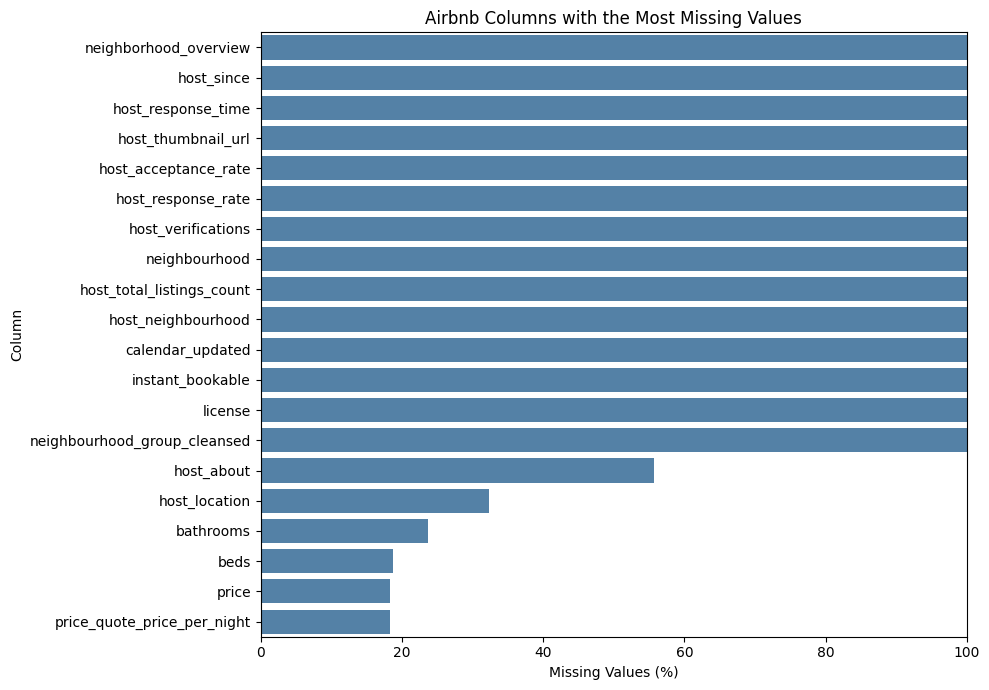

In [4]:
# Add code here 🔧
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percent": df.isna().mean() * 100
}).sort_values("Missing Count", ascending=False)

display(missing_summary)

print("Top 3 columns with the most missing values:")
display(missing_summary.head(3))

missing_columns = missing_summary[
    missing_summary["Missing Count"] > 0
].head(20)

if not missing_columns.empty:
    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=missing_columns,
        x="Missing Percent",
        y=missing_columns.index,
        color="steelblue"
    )
    plt.title("Airbnb Columns with the Most Missing Values")
    plt.xlabel("Missing Values (%)")
    plt.ylabel("Column")
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. he top three columns shown are neighborhood_overview, host_since, and host_response_time. Each is missing all 2,535 values, so they are tied at 100% missing.

2. Missing host_response_time could make it difficult to compare how quickly hosts respond to guests. Missing host_since prevents us from assessing host experience, while missing neighborhood_overview limits information about the surrounding area.

3. All three could be dropped from this analysis because they contain no usable information. I would keep the original dataset in case those fields can be recovered later.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [5]:
# Add code here 🔧
columns_to_drop = [
    "neighborhood_overview",
    "host_since",
    "host_response_time"
]

df = df.drop(columns=columns_to_drop)

print("Dropped columns:", columns_to_drop)
print("Remaining columns:", df.shape[1])
print(
    "All selected columns removed:",
    all(column not in df.columns for column in columns_to_drop)
)

display(df.head())

Dropped columns: ['neighborhood_overview', 'host_since', 'host_response_time']
Remaining columns: 87
All selected columns removed: True


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,50904,https://www.airbnb.com/rooms/50904,20260629161552,2026-06-29,city scrape,Boutique room in Antwerp's fashion district,Welcome to a vintage-styled private room in a ...,https://a0.muscache.com/pictures/12996741/1ccb...,234077,https://www.airbnb.com/users/show/234077,...,5.00,5.00,5.00,NaN,NaN,25,18,5,0,0.02
1,345959,https://www.airbnb.com/rooms/345959,20260629161552,2026-06-29,city scrape,Marleen's home in Antwerp city,"your entire, private groundfloor 2-bedroom apa...",https://a0.muscache.com/pictures/11642662/f9b6...,1754396,https://www.airbnb.com/users/show/1754396,...,4.89,4.62,4.83,NaN,NaN,1,1,0,0,0.90
2,366252,https://www.airbnb.com/rooms/366252,20260629161552,2026-06-29,city scrape,ROOM IN FAMILY HOME near C. Station,"In the Antwerp district of Borgerhout, we live...",https://a0.muscache.com/pictures/airflow/Hosti...,1820186,https://www.airbnb.com/users/show/1820186,...,4.90,4.43,4.66,NaN,NaN,2,0,2,0,0.93
3,636664,https://www.airbnb.com/rooms/636664,20260629161552,2026-06-29,city scrape,"sunny rooftop apartment, sleeps 2-5",Centrally located two-bedroom rooftop apartmen...,https://a0.muscache.com/pictures/9944653/62c01...,462975,https://www.airbnb.com/users/show/462975,...,4.83,4.37,4.43,NaN,NaN,1,1,0,0,0.81
4,772842,https://www.airbnb.com/rooms/772842,20260629161552,2026-06-29,city scrape,Loftstyle App w/ Easy parking & amazing views,If you're looking for a special getaway walkin...,https://a0.muscache.com/pictures/hosting/Hosti...,4050173,https://www.airbnb.com/users/show/4050173,...,4.77,4.47,4.35,NaN,NaN,1,1,0,0,0.51


### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. I dropped neighborhood_overview, host_since, and host_response_time.

2. All three columns were completely empty. Although these fields could be useful if populated, they provide no information for comparing listings or hosts in this dataset.

3. Leaving them in could cause problems if someone tried to use them in a dashboard or model without checking their completeness. Dropping them makes the working dataset easier to use without removing any actual recorded values.



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [8]:
# Your code for converting column data types 🔧
# Fill missing host locations with an explicit category
df["host_location"] = df["host_location"].fillna("Unknown")

# Flag missing review ratings without inventing a score
df["review_scores_rating_missing"] = (
    df["review_scores_rating"].isna()
)

print(
    "Missing host locations after cleaning:",
    df["host_location"].isna().sum()
)

print(
    "Listings flagged as missing a review rating:",
    df["review_scores_rating_missing"].sum()
)

display(
    df[[
        "host_location",
        "review_scores_rating",
        "review_scores_rating_missing"
    ]].head(10)
)

Missing host locations after cleaning: 0
Listings flagged as missing a review rating: 426


,host_location,review_scores_rating,review_scores_rating_missing
0,"Antwerp, Belgium",5.00,False
1,"Antwerp, Belgium",4.83,False
2,"Antwerp, Belgium",4.66,False
3,"Edegem, Belgium",4.56,False
4,"Antwerpen, Belgium",4.48,False
5,"Antwerp, Belgium",4.67,False
6,"Antwerp, Belgium",4.81,False
7,"Antwerp, Belgium",4.59,False
8,"Antwerp, Belgium",4.57,False
9,"Ghent, Belgium",4.61,False


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. I cleaned host_location and review_scores_rating. There were 821 missing host locations and 426 missing review ratings.

2. I filled missing host locations with “Unknown” so they remain clearly identified. For review ratings, I added a column that flags missing scores instead of assigning a rating that the listing did not actually receive.

3. “Unknown” groups together hosts whose locations may be different. Keeping missing ratings avoids inventing scores, but anyone using the data still needs to handle those missing values before modeling or comparing ratings.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

In [9]:
# Clean or adjust your dataset 🔧
print("Original price values:")
display(df["price"].head(10))

# Remove currency symbols, commas, and surrounding spaces
price_text = (
    df["price"]
    .astype("string")
    .str.replace(r"[$€£,]", "", regex=True)
    .str.strip()
)

# Convert prices to numbers; invalid entries become missing
missing_before = df["price"].isna().sum()
df["price"] = pd.to_numeric(price_text, errors="coerce")

print("Price data type:", df["price"].dtype)
print("Missing prices:", df["price"].isna().sum())
print(
    "Additional missing values from conversion:",
    df["price"].isna().sum() - missing_before
)

display(df["price"].describe())
display(df[["price"]].head(10))

Original price values:


,price
0,$204.00
1,$94.50
2,$63.00
3,$171.50
4,$80.43
5,$204.00
6,$48.86
7,$88.00
8,$90.00
9,$175.00


Price data type: Float64
Missing prices: 466
Additional missing values from conversion: 0


,price
count,2069.0
mean,175.939802
std,178.838613
min,6.46
25%,102.71
50%,139.5
75%,195.0
max,4565.0


,price
0,204.0
1,94.5
2,63.0
3,171.5
4,80.43
5,204.0
6,48.86
7,88.0
8,90.0
9,175.0


### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. I fixed the price column, which was stored as text instead of numbers.

2. I removed currency symbols, commas, and extra spaces, then converted the values to a numeric format. I kept missing prices as missing rather than assigning made up amounts.

3. This allows prices to be used in calculations, charts, and comparisons. It also prepares the column for later transformations, while keeping unknown prices separate from actual recorded prices.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [10]:
# Add code here 🔧
# Check for exact duplicate rows
exact_duplicates = df.duplicated().sum()
print("Exact duplicate rows:", exact_duplicates)

df = df.drop_duplicates().copy()

# Check for repeated listing IDs after removing exact duplicates
duplicate_ids = df.duplicated(subset=["id"]).sum()
print("Duplicate listing IDs after removing exact duplicates:", duplicate_ids)

if duplicate_ids > 0:
    display(
        df[df.duplicated(subset=["id"], keep=False)]
        .sort_values("id")
    )
else:
    print("Each listing ID is unique.")

print("Remaining rows:", len(df))

Exact duplicate rows: 0
Duplicate listing IDs after removing exact duplicates: 0
Each listing ID is unique.
Remaining rows: 2535


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. I found no exact duplicate rows and no duplicate listing IDs. All 2,535 listings had unique IDs.

2. I checked both full rows and listing IDs. Since neither check found duplicates, no records needed to be removed.

3. Duplicate listings could inflate listing counts and revenue estimates or cause the same property to appear more than once in a dashboard.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [11]:
# export csv here 🔧
df.to_csv("/content/cleaned_airbnb_data_6.csv", index=False)

print("Saved: cleaned_airbnb_data_6.csv")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Saved: cleaned_airbnb_data_6.csv
Rows: 2535
Columns: 88


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. Choosing how to handle missing values took the most thought. The main challenge was applying the class concepts and deciding when to fill a value versus flag it as missing.  
2. I dropped neighborhood_overview, host_since, and host_response_time because all three were completely empty. I kept listings with missing review ratings and flagged them instead of making up scores.  
3. Pricing analysts could use the numeric price column to calculate averages and compare listings. The missing-rating flag also helps a business team distinguish recorded ratings from unavailable ones.  
4. I would investigate unusual prices and check whether missing bedrooms, bathrooms, and beds could be recovered from other listing information. I would also review the remaining empty columns for relevance.  
5. This relates to my learning outcome of using Python to build and evaluate financial forecasting models. Reliable inputs matter because missing or incorrectly formatted data can lead to misleading predictions and decisions.  


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"